# 01_data_understanding

EduPredict — generated notebook. All statistics and results must be calculated from the actual dataset.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = Path("../data/raw/StudentPerformanceFactors.csv")
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nDtypes:")
print(df.dtypes)
print("\nMissing:")
print(df.isna().sum())
print("\nDuplicates:", df.duplicated().sum())


Shape: (6607, 20)
Columns: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

Dtypes:
Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabilities           

In [2]:
numerical_columns = df.select_dtypes(include="number").columns.tolist()
categorical_columns = df.select_dtypes(exclude="number").columns.tolist()

print("Numerical:", numerical_columns)
print("Categorical:", categorical_columns)
display(df[numerical_columns].describe().T)


Numerical: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
Categorical: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6607.0,7.029060,1.468120,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6607.0,1.493719,1.230570,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6607.0,2.967610,1.031231,0.0,2.0,3.0,4.0,6.0
Exam_Score,6607.0,67.235659,3.890456,55.0,65.0,67.0,69.0,101.0


In [3]:
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_count"))


,missing_count
Parental_Education_Level,90
Teacher_Quality,78
Distance_from_Home,67


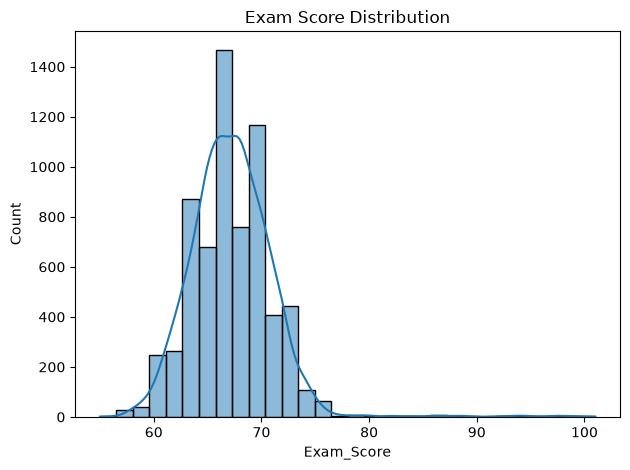

In [4]:
TARGET = "Exam_Score"
sns.histplot(df[TARGET], bins=30, kde=True)
plt.title("Exam Score Distribution")
plt.tight_layout()
plt.show()


In [5]:
# Check potentially invalid exam scores
invalid_scores = df[df["Exam_Score"] > 100]

print("Number of scores > 100:", len(invalid_scores))
print("\nInvalid score values:")
print(invalid_scores["Exam_Score"].value_counts().sort_index())

Number of scores > 100: 1

Invalid score values:
Exam_Score
101    1
Name: count, dtype: int64


In [6]:
print(df["Exam_Score"].describe())

print("\nScores below 0:")
print((df["Exam_Score"] < 0).sum())

print("\nScores above 100:")
print((df["Exam_Score"] > 100).sum())

count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64

Scores below 0:
0

Scores above 100:
1


In [7]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)
print("\nTotal missing values:", df.isnull().sum().sum())

Parental_Education_Level    90
Teacher_Quality             78
Distance_from_Home          67
dtype: int64

Total missing values: 235


In [9]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64


In [11]:
invalid_row = df[df["Exam_Score"] > 100]

display(invalid_row.T)

,1525
Hours_Studied,27
Attendance,98
Parental_Involvement,Low
Access_to_Resources,Medium
Extracurricular_Activities,Yes
Sleep_Hours,6
Previous_Scores,93
Motivation_Level,Low
Internet_Access,No
Tutoring_Sessions,5


In [12]:
print(invalid_row.to_dict("records"))

[{'Hours_Studied': 27, 'Attendance': 98, 'Parental_Involvement': 'Low', 'Access_to_Resources': 'Medium', 'Extracurricular_Activities': 'Yes', 'Sleep_Hours': 6, 'Previous_Scores': 93, 'Motivation_Level': 'Low', 'Internet_Access': 'No', 'Tutoring_Sessions': 5, 'Family_Income': 'High', 'Teacher_Quality': 'High', 'School_Type': 'Public', 'Peer_Influence': 'Positive', 'Physical_Activity': 3, 'Learning_Disabilities': 'No', 'Parental_Education_Level': 'High School', 'Distance_from_Home': 'Moderate', 'Gender': 'Female', 'Exam_Score': 101}]


In [13]:
print(
    df["Exam_Score"]
      .value_counts()
      .sort_index()
      .tail(15)
)

Exam_Score
86     4
87     2
88     3
89     3
91     1
92     2
93     2
94     4
95     2
96     1
97     3
98     3
99     2
100    1
101    1
Name: count, dtype: int64


In [14]:
print("Scores > 100:", (df["Exam_Score"] > 100).sum())
print("Scores <= 100:", (df["Exam_Score"] <= 100).sum())

Scores > 100: 1
Scores <= 100: 6606


In [15]:
display(invalid_row.T)

,1525
Hours_Studied,27
Attendance,98
Parental_Involvement,Low
Access_to_Resources,Medium
Extracurricular_Activities,Yes
Sleep_Hours,6
Previous_Scores,93
Motivation_Level,Low
Internet_Access,No
Tutoring_Sessions,5


In [17]:
df_clean = df[df["Exam_Score"].between(0, 100)].copy()

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Removed rows:", len(df) - len(df_clean))
print(
    "Remaining invalid scores:",
    ((df_clean["Exam_Score"] < 0) | (df_clean["Exam_Score"] > 100)).sum()
)

Original shape: (6607, 20)
Cleaned shape: (6606, 20)
Removed rows: 1
Remaining invalid scores: 0


In [18]:
# Missing-value analysis
missing_summary = pd.DataFrame({
    "Missing_Count": df_clean.isnull().sum(),
    "Missing_Percentage": (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
})

missing_summary = (
    missing_summary[missing_summary["Missing_Count"] > 0]
    .sort_values("Missing_Count", ascending=False)
)

display(missing_summary)

,Missing_Count,Missing_Percentage
Parental_Education_Level,90,1.36
Teacher_Quality,78,1.18
Distance_from_Home,67,1.01


In [19]:
# Check whether missing values occur together in the same rows
rows_with_missing = df_clean.isnull().any(axis=1)

print("Rows containing at least one missing value:",
      rows_with_missing.sum())

print("Total missing cells:",
      df_clean.isnull().sum().sum())

Rows containing at least one missing value: 229
Total missing cells: 235


In [20]:
categorical_cols = df_clean.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(col)
    print(df_clean[col].value_counts(dropna=False))


Parental_Involvement
Parental_Involvement
Medium    3362
High      1908
Low       1336
Name: count, dtype: int64

Access_to_Resources
Access_to_Resources
Medium    3318
High      1975
Low       1313
Name: count, dtype: int64

Extracurricular_Activities
Extracurricular_Activities
Yes    3937
No     2669
Name: count, dtype: int64

Motivation_Level
Motivation_Level
Medium    3351
Low       1936
High      1319
Name: count, dtype: int64

Internet_Access
Internet_Access
Yes    6108
No      498
Name: count, dtype: int64

Family_Income
Family_Income
Low       2672
Medium    2666
High      1268
Name: count, dtype: int64

Teacher_Quality
Teacher_Quality
Medium    3925
High      1946
Low        657
NaN         78
Name: count, dtype: int64

School_Type
School_Type
Public     4597
Private    2009
Name: count, dtype: int64

Peer_Influence
Peer_Influence
Positive    2637
Neutral     2592
Negative    1377
Name: count, dtype: int64

Learning_Disabilities
Learning_Disabilities
No     5911
Yes     695
N

/var/folders/1x/v3n56khd0s7_pv3fg7v1wvmm0000gn/T/ipykernel_39980/2234694495.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include="object").columns


In [24]:
missing_summary = pd.DataFrame({
    "Missing_Count": df_clean.isnull().sum(),
    "Missing_Percentage": (
        df_clean.isnull().sum() / len(df_clean) * 100
    ).round(2)
})

missing_summary = (
    missing_summary[missing_summary["Missing_Count"] > 0]
    .sort_values("Missing_Count", ascending=False)
)

display(missing_summary)

,Missing_Count,Missing_Percentage
Parental_Education_Level,90,1.36
Teacher_Quality,78,1.18
Distance_from_Home,67,1.01


In [22]:
rows_with_missing = df_clean.isnull().any(axis=1)

print("Rows containing at least one missing value:", rows_with_missing.sum())
print("Total missing cells:", df_clean.isnull().sum().sum())

Rows containing at least one missing value: 229
Total missing cells: 235


In [23]:
missing_cols = [
    "Parental_Education_Level",
    "Teacher_Quality",
    "Distance_from_Home"
]

print(
    df_clean[missing_cols]
    .isnull()
    .sum(axis=1)
    .value_counts()
    .sort_index()
)

0    6377
1     223
2       6
Name: count, dtype: int64


In [25]:
categorical_cols = df_clean.select_dtypes(include=["object", "str"]).columns